# Word Embeddings Visualization: Word2Vec and GloVe


## 1. Install libraries

In [1]:
!pip install -q gensim scikit-learn matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 33.6 MB/s eta 0:00:00


In [15]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

## 2. What are word embeddings?

A word embedding maps a word to a numerical vector. Words used in similar contexts may have vectors pointing in similar directions.

- **Word2Vec:** learns vectors through context prediction (CBOW or Skip-gram).
- **GloVe:** learns vectors from global word–word co-occurrence statistics.
- **Cosine similarity:** compares vector directions; values closer to 1 indicate more similar directions.
- **PCA/t-SNE:** reduce high-dimensional vectors to 2D for visualization. The 2D plot is only an approximation.

## 3. Prepare a small Word2Vec corpus

In [16]:
sentences = [
    "the king rules the kingdom", "the queen rules the kingdom",
    "the king and queen live in the palace",
    "a man and a woman walk in the garden",
    "the boy plays with the girl", "the girl and boy read a book",
    "a cat sits on the mat", "the dog sits near the cat",
    "the dog and cat are animals", "the apple and orange are fruit",
    "the apple is a fruit", "the orange is a fruit",
    "a doctor works in the hospital", "a nurse works in the hospital",
    "the doctor and nurse help people",
    "python is a programming language", "java is a programming language",
    "python and java are used for programming",
    "a computer runs software", "a laptop is a computer"
]
tokenized_sentences = [s.lower().split() for s in sentences]
print("Sentences:", len(tokenized_sentences))
for i in range(5):
    print(tokenized_sentences[i])

Sentences: 20
['the', 'king', 'rules', 'the', 'kingdom']
['the', 'queen', 'rules', 'the', 'kingdom']
['the', 'king', 'and', 'queen', 'live', 'in', 'the', 'palace']
['a', 'man', 'and', 'a', 'woman', 'walk', 'in', 'the', 'garden']
['the', 'boy', 'plays', 'with', 'the', 'girl']
Example: ['the', 'king', 'rules', 'the', 'kingdom']


## 4. Train Word2Vec (Skip-gram)

In [4]:
w2v_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=50,
    window=3,
    min_count=1,
    workers=2,
    sg=1,
    epochs=200,
    seed=42
)
print("Vocabulary size:", len(w2v_model.wv))
print("'king' vector shape:", w2v_model.wv["king"].shape)
print("First 10 values:", np.round(w2v_model.wv["king"][:10], 3))

Vocabulary size: 48
'king' vector shape: (50,)
First 10 values: [ 0.023 -0.046  0.016  0.018  0.053  0.032 -0.061  0.046 -0.043  0.016]


## 5. Find similar words

In [21]:
for word in ["king", "cat", "doctor", "python","walk"]:
    print(f"\nMost similar to {word!r}:")
    for candidate, score in w2v_model.wv.most_similar(word, topn=5):
        print(f"  {candidate:12s} {score:.3f}")


Most similar to 'king':
  in           0.985
  the          0.985
  and          0.984
  a            0.983
  dog          0.980

Most similar to 'cat':
  and          0.989
  the          0.988
  a            0.988
  boy          0.986
  are          0.985

Most similar to 'doctor':
  in           0.974
  the          0.974
  dog          0.970
  and          0.970
  sits         0.968

Most similar to 'python':
  a            0.990
  and          0.987
  is           0.987
  the          0.985
  dog          0.983

Most similar to 'walk':
  and          0.990
  the          0.990
  a            0.989
  in           0.986
  dog          0.985


## 6. Cosine similarity

In [23]:
pairs = [("king", "queen"), ("cat", "dog"), ("doctor", "nurse"),
         ("python", "java"), ("king", "apple"),("the","a")]
rows = []
for a, b in pairs:
    score = cosine_similarity([w2v_model.wv[a]], [w2v_model.wv[b]])[0, 0]
    rows.append({"word_1": a, "word_2": b, "cosine_similarity": round(float(score), 4)})
pd.DataFrame(rows)

,word_1,word_2,cosine_similarity
0,king,queen,0.9779
1,cat,dog,0.9828
2,doctor,nurse,0.9577
3,python,java,0.9748
4,king,apple,0.9532
5,the,a,0.9937


## 7. Visualize Word2Vec with PCA

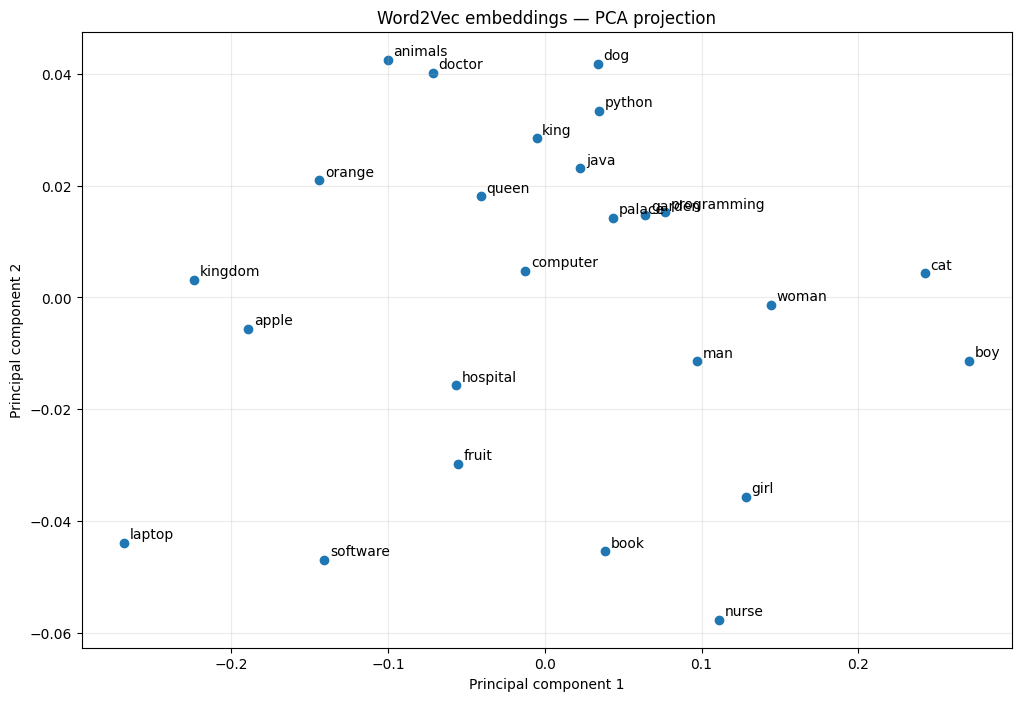

Variance captured by 2 components: 0.747


In [7]:
words = ["king", "queen", "kingdom", "palace", "man", "woman", "boy", "girl",
         "cat", "dog", "animals", "apple", "orange", "fruit", "doctor", "nurse",
         "hospital", "python", "java", "programming", "computer", "laptop",
         "software", "book", "garden"]
words = [w for w in words if w in w2v_model.wv]
vectors = np.array([w2v_model.wv[w] for w in words])
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)
plt.figure(figsize=(12, 8))
plt.scatter(coords[:, 0], coords[:, 1])
for i, word in enumerate(words):
    plt.annotate(word, (coords[i, 0], coords[i, 1]), xytext=(4, 3), textcoords="offset points")
plt.title("Word2Vec embeddings — PCA projection")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.grid(alpha=0.25)
plt.show()
print("Variance captured by 2 components:", round(float(pca.explained_variance_ratio_.sum()), 3))

## 8. Optional: visualize Word2Vec with t-SNE

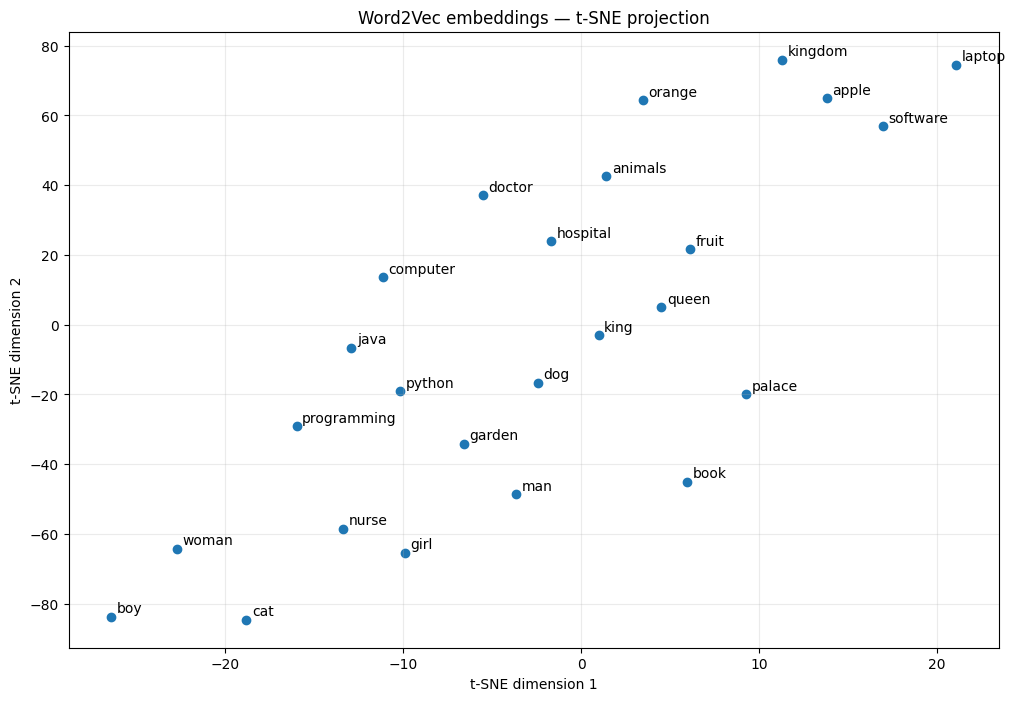

In [8]:
perplexity = min(5, len(words) - 1)
tsne = TSNE(n_components=2, perplexity=perplexity, init="pca",
            learning_rate="auto", random_state=42)
coords_tsne = tsne.fit_transform(vectors)
plt.figure(figsize=(12, 8))
plt.scatter(coords_tsne[:, 0], coords_tsne[:, 1])
for i, word in enumerate(words):
    plt.annotate(word, (coords_tsne[i, 0], coords_tsne[i, 1]),
                 xytext=(4, 3), textcoords="offset points")
plt.title("Word2Vec embeddings — t-SNE projection")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.grid(alpha=0.25)
plt.show()

## 9. Load pretrained GloVe vectors

The model `glove-wiki-gigaword-50` is pretrained on a large corpus. Downloading may take a while and requires internet access.

In [9]:
import gensim.downloader as api
glove_model = api.load("glove-wiki-gigaword-50")
print("GloVe vocabulary size:", len(glove_model.key_to_index))
print("'king' vector shape:", glove_model["king"].shape)

[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe vocabulary size: 400000
'king' vector shape: (50,)


## 10. Explore GloVe similarity

In [10]:
for word in ["king", "cat", "doctor", "computer"]:
    print(f"\nGloVe words similar to {word!r}:")
    for candidate, score in glove_model.most_similar(word, topn=5):
        print(f"  {candidate:15s} {score:.3f}")


GloVe words similar to 'king':
  prince          0.824
  queen           0.784
  ii              0.775
  emperor         0.774
  son             0.767

GloVe words similar to 'cat':
  dog             0.922
  rabbit          0.849
  monkey          0.804
  rat             0.789
  cats            0.787

GloVe words similar to 'doctor':
  nurse           0.798
  physician       0.797
  patient         0.761
  child           0.756
  teacher         0.754

GloVe words similar to 'computer':
  computers       0.917
  software        0.881
  technology      0.853
  electronic      0.813
  internet        0.806


In [11]:
glove_pairs = [("king", "queen"), ("cat", "dog"), ("doctor", "nurse"),
               ("python", "java"), ("king", "apple")]
rows = []
for a, b in glove_pairs:
    score = cosine_similarity([glove_model[a]], [glove_model[b]])[0, 0]
    rows.append({"word_1": a, "word_2": b, "cosine_similarity": round(float(score), 4)})
pd.DataFrame(rows)

,word_1,word_2,cosine_similarity
0,king,queen,0.7839
1,cat,dog,0.9218
2,doctor,nurse,0.7977
3,python,java,0.4767
4,king,apple,0.3047


## 11. Visualize GloVe with PCA

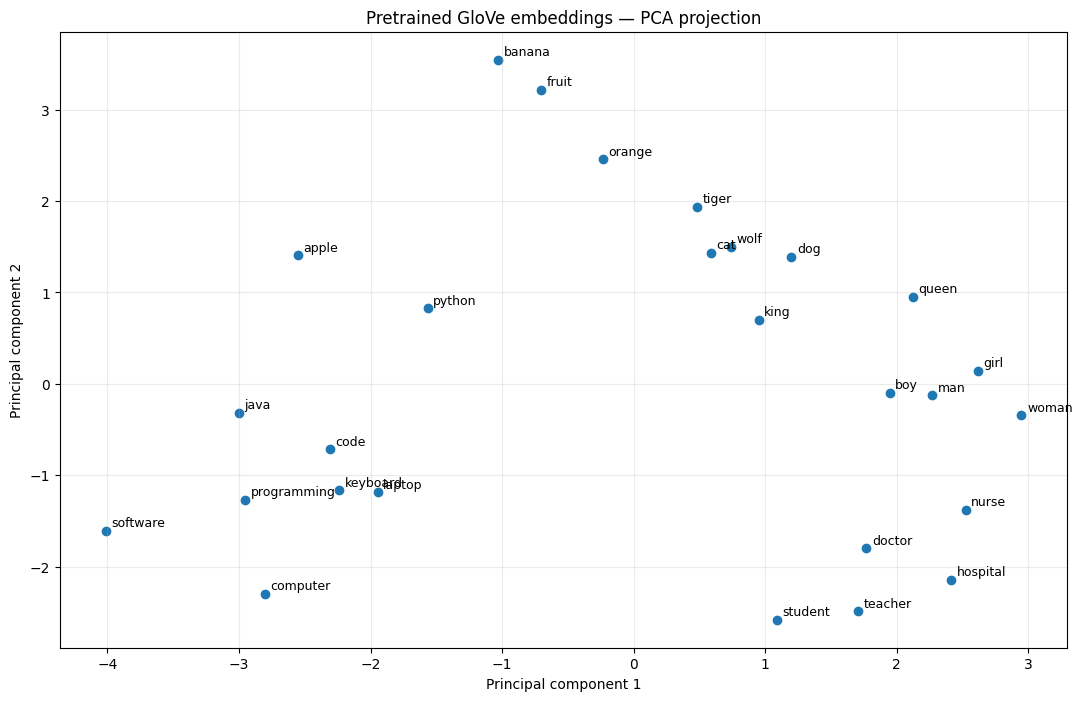

In [12]:
glove_words = ["king", "queen", "man", "woman", "boy", "girl", "cat", "dog",
               "wolf", "tiger", "apple", "orange", "banana", "fruit", "doctor",
               "nurse", "hospital", "teacher", "student", "computer", "laptop",
               "software", "keyboard", "python", "java", "programming", "code"]
glove_words = [w for w in glove_words if w in glove_model.key_to_index]
glove_vectors = np.array([glove_model[w] for w in glove_words])
glove_pca = PCA(n_components=2, random_state=42)
glove_coords = glove_pca.fit_transform(glove_vectors)
plt.figure(figsize=(13, 8))
plt.scatter(glove_coords[:, 0], glove_coords[:, 1])
for i, word in enumerate(glove_words):
    plt.annotate(word, (glove_coords[i, 0], glove_coords[i, 1]),
                 xytext=(4, 3), textcoords="offset points", fontsize=9)
plt.title("Pretrained GloVe embeddings — PCA projection")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.grid(alpha=0.25)
plt.show()

## 12. Word analogy

In [13]:
# Example: king - man + woman may return queen among the nearest words.
# Results can vary and may reflect biases in the training data.
glove_model.most_similar(positive=["king", "woman"], negative=["man"], topn=5)

[('queen', 0.8523604273796082),
 ('throne', 0.7664334177970886),
 ('prince', 0.7592144012451172),
 ('daughter', 0.7473883628845215),
 ('elizabeth', 0.7460219860076904)]